<a href="https://colab.research.google.com/github/smshozab/AG-AquaSense/blob/main/AAIn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview

This notebook prepares the **sensor data pipeline** and optionally supports image dataset inspection.

### Important Note
- Image dataset was **used in this run**.
- The **sensor pipeline was executed**.

### What this notebook does
- Load and visualize fish disease images (7 classes)
- Simulate IoT sensor data:
  - DO, pH, Temperature, TAN, Turbidity
- Apply preprocessing:
  - 5-minute median filter (removes noise/spikes)
  - 24-hour rolling z-score (detects anomalies)
- Build final **10D feature vector**:

  [do, ph, temp, tan, turbidity, a_do, a_ph, a_temp, a_tan, a_turb]

### Key outputs
- Sensor time-series plots (raw vs filtered)
- Anomaly detection plots
- Final dataset: `sensor_feature_vector_10d.csv`

### Usage
- Output is used in Notebook 4 (sensor model)

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [45]:
# =========================
# CONFIG
# =========================

# Update this path if you have the real image dataset
# Expected structure:
# dataset_root/
#   Bacterial Red Disease/
#   Aeromoniasis/
#   Bacterial Gill Disease/
#   Saprolegniasis/
#   Healthy Fish/
#   Parasitic Diseases/
#   White Tail Disease/

IMAGE_DATASET_ROOT = Path("/content/Dataset.zip")  # change if needed

DISEASE_CLASSES = [
    "Bacterial Red disease",
    "Bacterial diseases - Aeromoniasis",
    "Bacterial gill disease",
    "Fungal diseases Saprolegniasis",
    "Healthy Fish",
    "Parasitic diseases",
    "Viral diseases White tail disease"
]

SENSOR_COLUMNS = ["do", "ph", "temp", "tan", "turbidity"]

# Simulation settings
SIM_DAYS = 14                     # 14 days of data
FREQ = "60s"                     # every 60 seconds
TANK_ID = "tank_1"

# Smoothing / anomaly settings
MEDIAN_FILTER_WINDOW = 5         # 5 minutes since data is every 60 sec
ROLLING_Z_WINDOW = 24 * 60       # 24 hours = 1440 points at 1-minute frequency
MIN_PERIODS_Z = 60               # avoid unstable z-score at very beginning
EPS = 1e-8

In [46]:
def list_images_in_class_folder(class_dir: Path):
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    if not class_dir.exists():
        return []
    return [p for p in class_dir.iterdir() if p.suffix.lower() in valid_exts]


def get_image_dataset_summary(dataset_root: Path, class_names):
    summary = []
    for cls in class_names:
        class_dir = dataset_root / cls
        images = list_images_in_class_folder(class_dir)
        summary.append({
            "class_name": cls,
            "num_images": len(images),
            "class_dir_exists": class_dir.exists()
        })
    return pd.DataFrame(summary)


def plot_class_distribution(summary_df):
    plt.figure(figsize=(10, 5))
    plt.bar(summary_df["class_name"], summary_df["num_images"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution")
    plt.tight_layout()
    plt.show()


def show_sample_images(dataset_root: Path, class_names, samples_per_class=3, image_size=(160, 160)):
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(4 * samples_per_class, 3 * len(class_names)))

    if len(class_names) == 1:
        axes = np.array([axes])
    if samples_per_class == 1:
        axes = axes.reshape(len(class_names), 1)

    for row_idx, cls in enumerate(class_names):
        class_dir = dataset_root / cls
        images = list_images_in_class_folder(class_dir)

        chosen = random.sample(images, min(samples_per_class, len(images))) if len(images) > 0 else []

        for col_idx in range(samples_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis("off")

            if col_idx < len(chosen):
                try:
                    img = Image.open(chosen[col_idx]).convert("RGB").resize(image_size)
                    ax.imshow(img)
                    ax.set_title(f"{cls}\n{chosen[col_idx].name}", fontsize=9)
                except Exception as e:
                    ax.text(0.5, 0.5, f"Error loading\n{chosen[col_idx].name}", ha="center", va="center")
            else:
                ax.text(0.5, 0.5, f"No image", ha="center", va="center")

    plt.tight_layout()
    plt.show()

Image dataset found at: /content/unzipped_dataset/Dataset


,class_name,num_images,class_dir_exists
0,Bacterial Red disease,250,True
1,Bacterial diseases - Aeromoniasis,250,True
2,Bacterial gill disease,250,True
3,Fungal diseases Saprolegniasis,250,True
4,Healthy Fish,250,True
5,Parasitic diseases,250,True
6,Viral diseases White tail disease,250,True


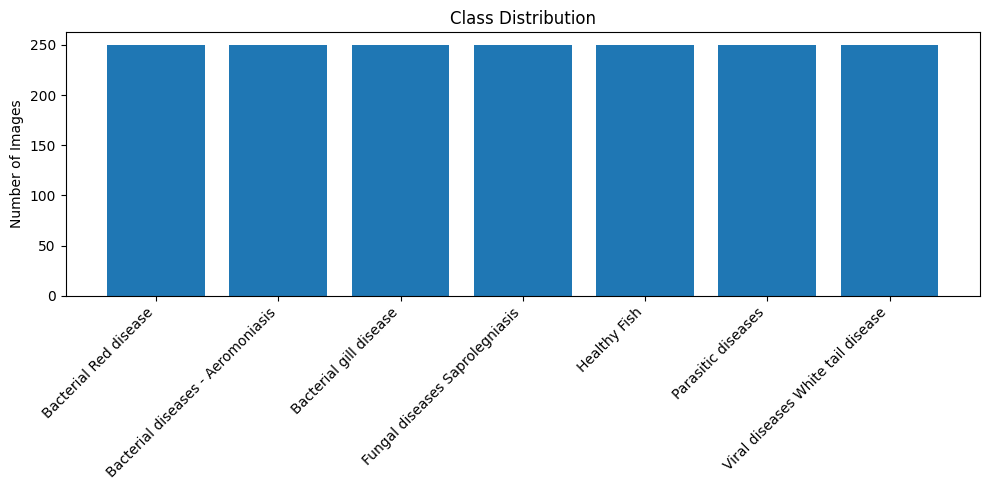

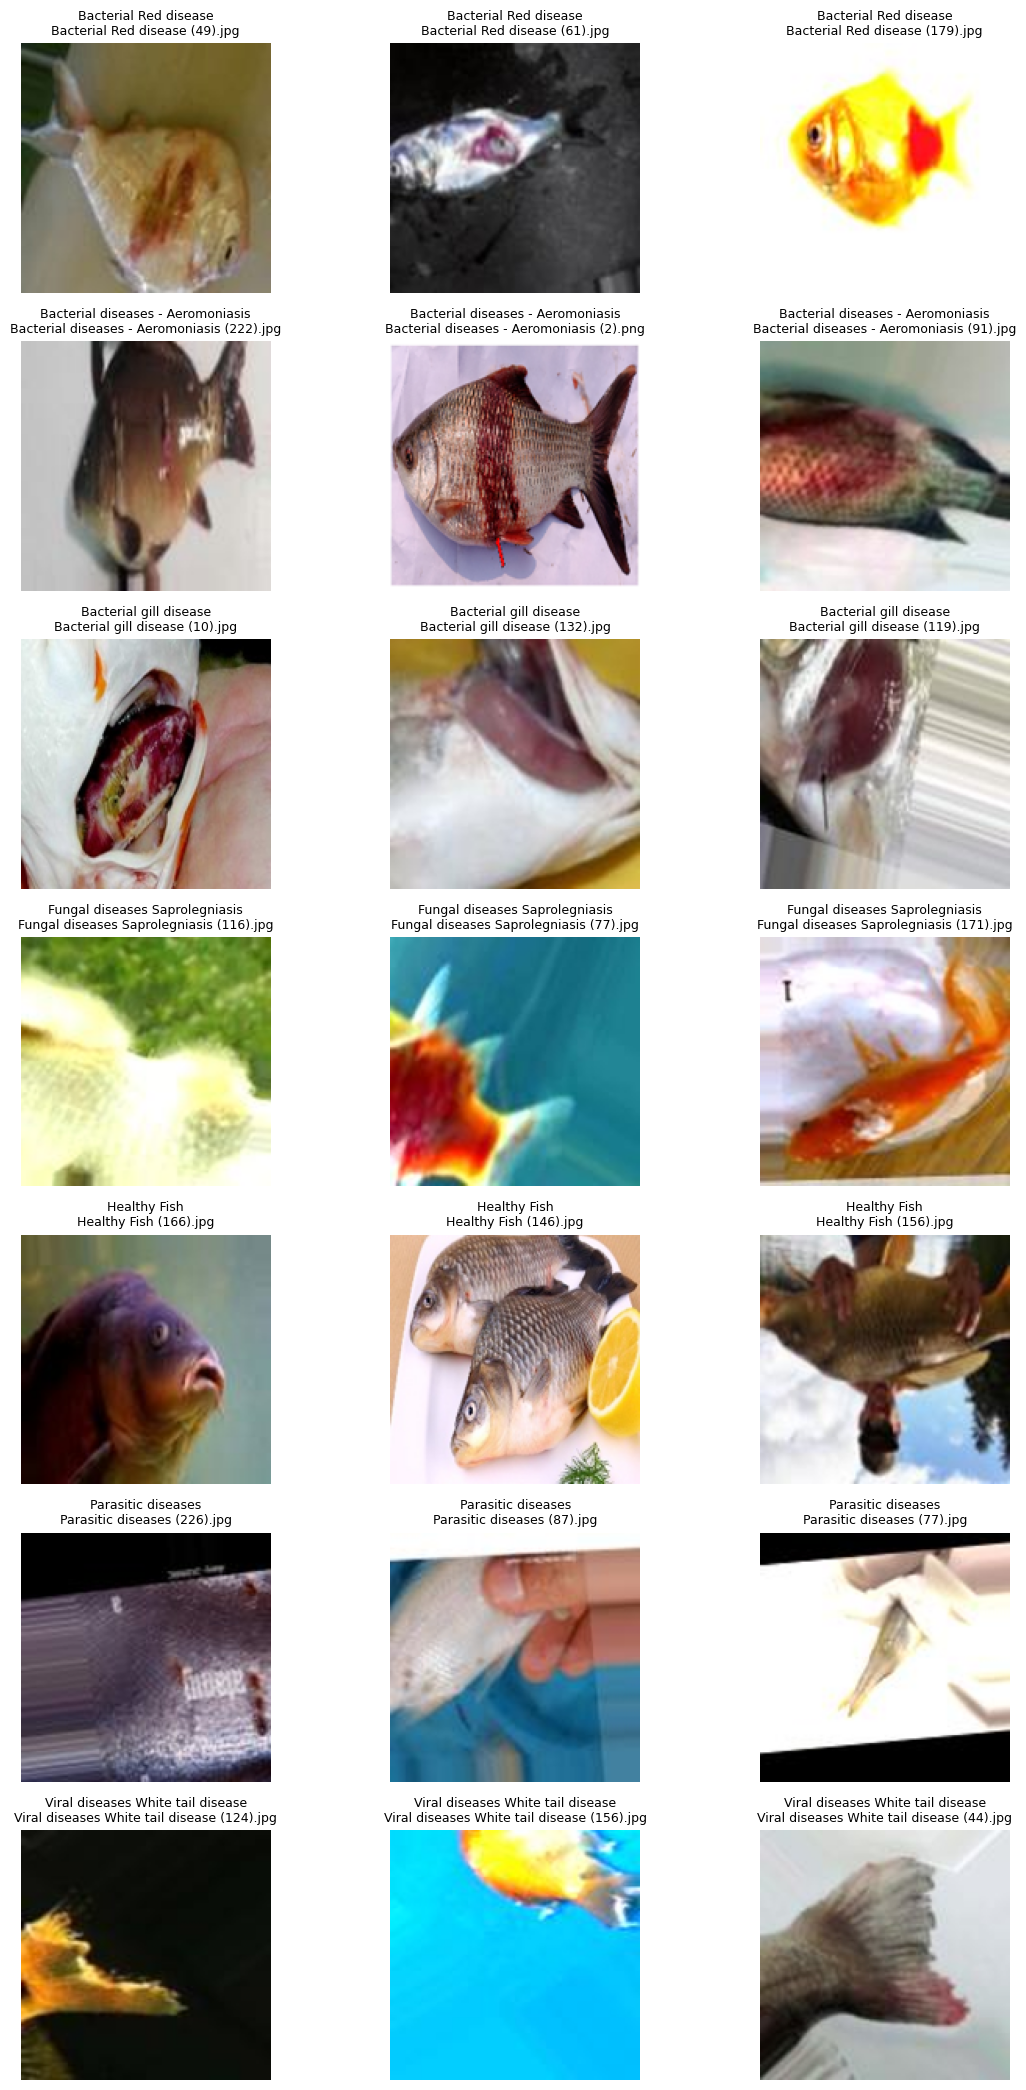

In [47]:
import zipfile

# Define the directory where the dataset will be extracted
EXTRACT_PATH = Path("/content/unzipped_dataset")

# Unzip the dataset if it hasn't been unzipped already
if not EXTRACT_PATH.exists():
    print(f"Unzipping {IMAGE_DATASET_ROOT.name} to {EXTRACT_PATH}")
    with zipfile.ZipFile(IMAGE_DATASET_ROOT, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Unzipping complete.")

# Update IMAGE_DATASET_ROOT to point to the unzipped directory
IMAGE_DATASET_ROOT = Path("/content/unzipped_dataset/Dataset")

if IMAGE_DATASET_ROOT.exists():
    print(f"Image dataset found at: {IMAGE_DATASET_ROOT.resolve()}")
    image_summary_df = get_image_dataset_summary(IMAGE_DATASET_ROOT, DISEASE_CLASSES)
    display(image_summary_df)

    plot_class_distribution(image_summary_df)
    show_sample_images(IMAGE_DATASET_ROOT, DISEASE_CLASSES, samples_per_class=3)
else:
    print("Image dataset folder not found.")
    print("Skipping real image loading for now.")
    print(f"Expected path: {IMAGE_DATASET_ROOT.resolve()}")

In [36]:
print(f"Contents of {EXTRACT_PATH}:")
for item in EXTRACT_PATH.iterdir():
    print(item.name)

Contents of /content/unzipped_dataset:
Dataset


In [6]:
def generate_time_index(days=14, freq="60s"):
    periods = int(pd.Timedelta(days=days) / pd.Timedelta(freq))
    return pd.date_range(start="2025-01-01 00:00:00", periods=periods, freq=freq)


def circadian_wave(length, amplitude=1.0, phase=0.0):
    x = np.arange(length)
    return amplitude * np.sin(2 * np.pi * x / 1440 + phase)  # daily cycle for minute-level data


def add_spikes(series, n_spikes=20, spike_scale=1.0):
    series = series.copy()
    spike_indices = np.random.choice(len(series), size=n_spikes, replace=False)
    spike_values = np.random.normal(loc=0, scale=spike_scale, size=n_spikes)
    series[spike_indices] += spike_values
    return series


def clamp(series, low=None, high=None):
    arr = np.array(series, dtype=float)
    if low is not None:
        arr = np.maximum(arr, low)
    if high is not None:
        arr = np.minimum(arr, high)
    return arr

In [7]:
def simulate_sensor_dataset(days=14, freq="60s", tank_id="tank_1"):
    """
    Simulates five water-quality sensors:
    - do: dissolved oxygen
    - ph
    - temp
    - tan: total ammonia nitrogen
    - turbidity

    Includes:
    - circadian patterns
    - slow drift
    - random noise
    - transient spikes
    - a few stress periods
    """
    timestamps = generate_time_index(days=days, freq=freq)
    n = len(timestamps)

    # Base healthy-ish profiles
    do = 6.8 + circadian_wave(n, amplitude=0.5, phase=0.3) + np.random.normal(0, 0.12, n)
    ph = 7.4 + circadian_wave(n, amplitude=0.12, phase=1.0) + np.random.normal(0, 0.03, n)
    temp = 27.5 + circadian_wave(n, amplitude=0.8, phase=-0.4) + np.random.normal(0, 0.10, n)
    tan = 0.30 + circadian_wave(n, amplitude=0.05, phase=0.8) + np.random.normal(0, 0.02, n)
    turbidity = 9.0 + circadian_wave(n, amplitude=1.2, phase=0.1) + np.random.normal(0, 0.40, n)

    # Slow trends
    do += np.linspace(0.0, -0.4, n)
    tan += np.linspace(0.0, 0.15, n)
    turbidity += np.linspace(0.0, 1.2, n)

    # Inject transient spikes
    do = add_spikes(do, n_spikes=35, spike_scale=1.0)
    ph = add_spikes(ph, n_spikes=25, spike_scale=0.20)
    temp = add_spikes(temp, n_spikes=25, spike_scale=1.0)
    tan = add_spikes(tan, n_spikes=30, spike_scale=0.15)
    turbidity = add_spikes(turbidity, n_spikes=30, spike_scale=4.0)

    # Inject longer stress windows
    stress_windows = [
        (2 * 1440, 2 * 1440 + 360),   # day 3, 6 hours
        (7 * 1440, 7 * 1440 + 480),   # day 8, 8 hours
        (11 * 1440, 11 * 1440 + 300)  # day 12, 5 hours
    ]

    for start, end in stress_windows:
        do[start:end] -= np.random.uniform(0.8, 1.6)
        tan[start:end] += np.random.uniform(0.15, 0.30)
        turbidity[start:end] += np.random.uniform(2.0, 4.0)
        temp[start:end] += np.random.uniform(0.4, 1.0)

    # Physical plausibility clamps
    do = clamp(do, low=0.5, high=14.0)
    ph = clamp(ph, low=5.5, high=9.5)
    temp = clamp(temp, low=18.0, high=35.0)
    tan = clamp(tan, low=0.01, high=3.0)
    turbidity = clamp(turbidity, low=0.1, high=100.0)

    df = pd.DataFrame({
        "timestamp": timestamps,
        "tank_id": tank_id,
        "do": do,
        "ph": ph,
        "temp": temp,
        "tan": tan,
        "turbidity": turbidity
    })

    return df

In [8]:
sensor_df = simulate_sensor_dataset(days=SIM_DAYS, freq=FREQ, tank_id=TANK_ID)

print(sensor_df.shape)
display(sensor_df.head())
display(sensor_df.describe())

(20160, 7)


,timestamp,tank_id,do,ph,temp,tan,turbidity
0,2025-01-01 00:00:00,tank_1,7.007366,7.511361,27.131727,0.349024,8.739518
1,2025-01-01 00:01:00,tank_1,6.933231,7.477962,27.155445,0.380946,9.099069
2,2025-01-01 00:02:00,tank_1,7.029606,7.523930,27.204861,0.350220,9.234671
3,2025-01-01 00:03:00,tank_1,7.136704,7.509776,27.219940,0.321440,9.370712
4,2025-01-01 00:04:00,tank_1,6.927896,7.491881,27.244868,0.333364,9.525092


,timestamp,do,ph,temp,tan,turbidity
count,20160,20160.000000,20160.000000,20160.000000,20160.000000,20160.000000
mean,2025-01-07 23:59:30.000000256,6.534204,7.399734,27.539991,0.389426,9.732771
min,2025-01-01 00:00:00,3.804692,7.015396,25.068049,0.082658,0.100000
25%,2025-01-04 11:59:45,6.200328,7.319626,26.944761,0.333422,8.834389
50%,2025-01-07 23:59:30,6.515236,7.398996,27.535846,0.377123,9.620589
75%,2025-01-11 11:59:15,6.886017,7.479481,28.105438,0.424301,10.460628
max,2025-01-14 23:59:00,8.708108,7.902147,29.834755,0.796984,16.305945
std,NaN,0.422155,0.090351,0.618938,0.090006,1.230396


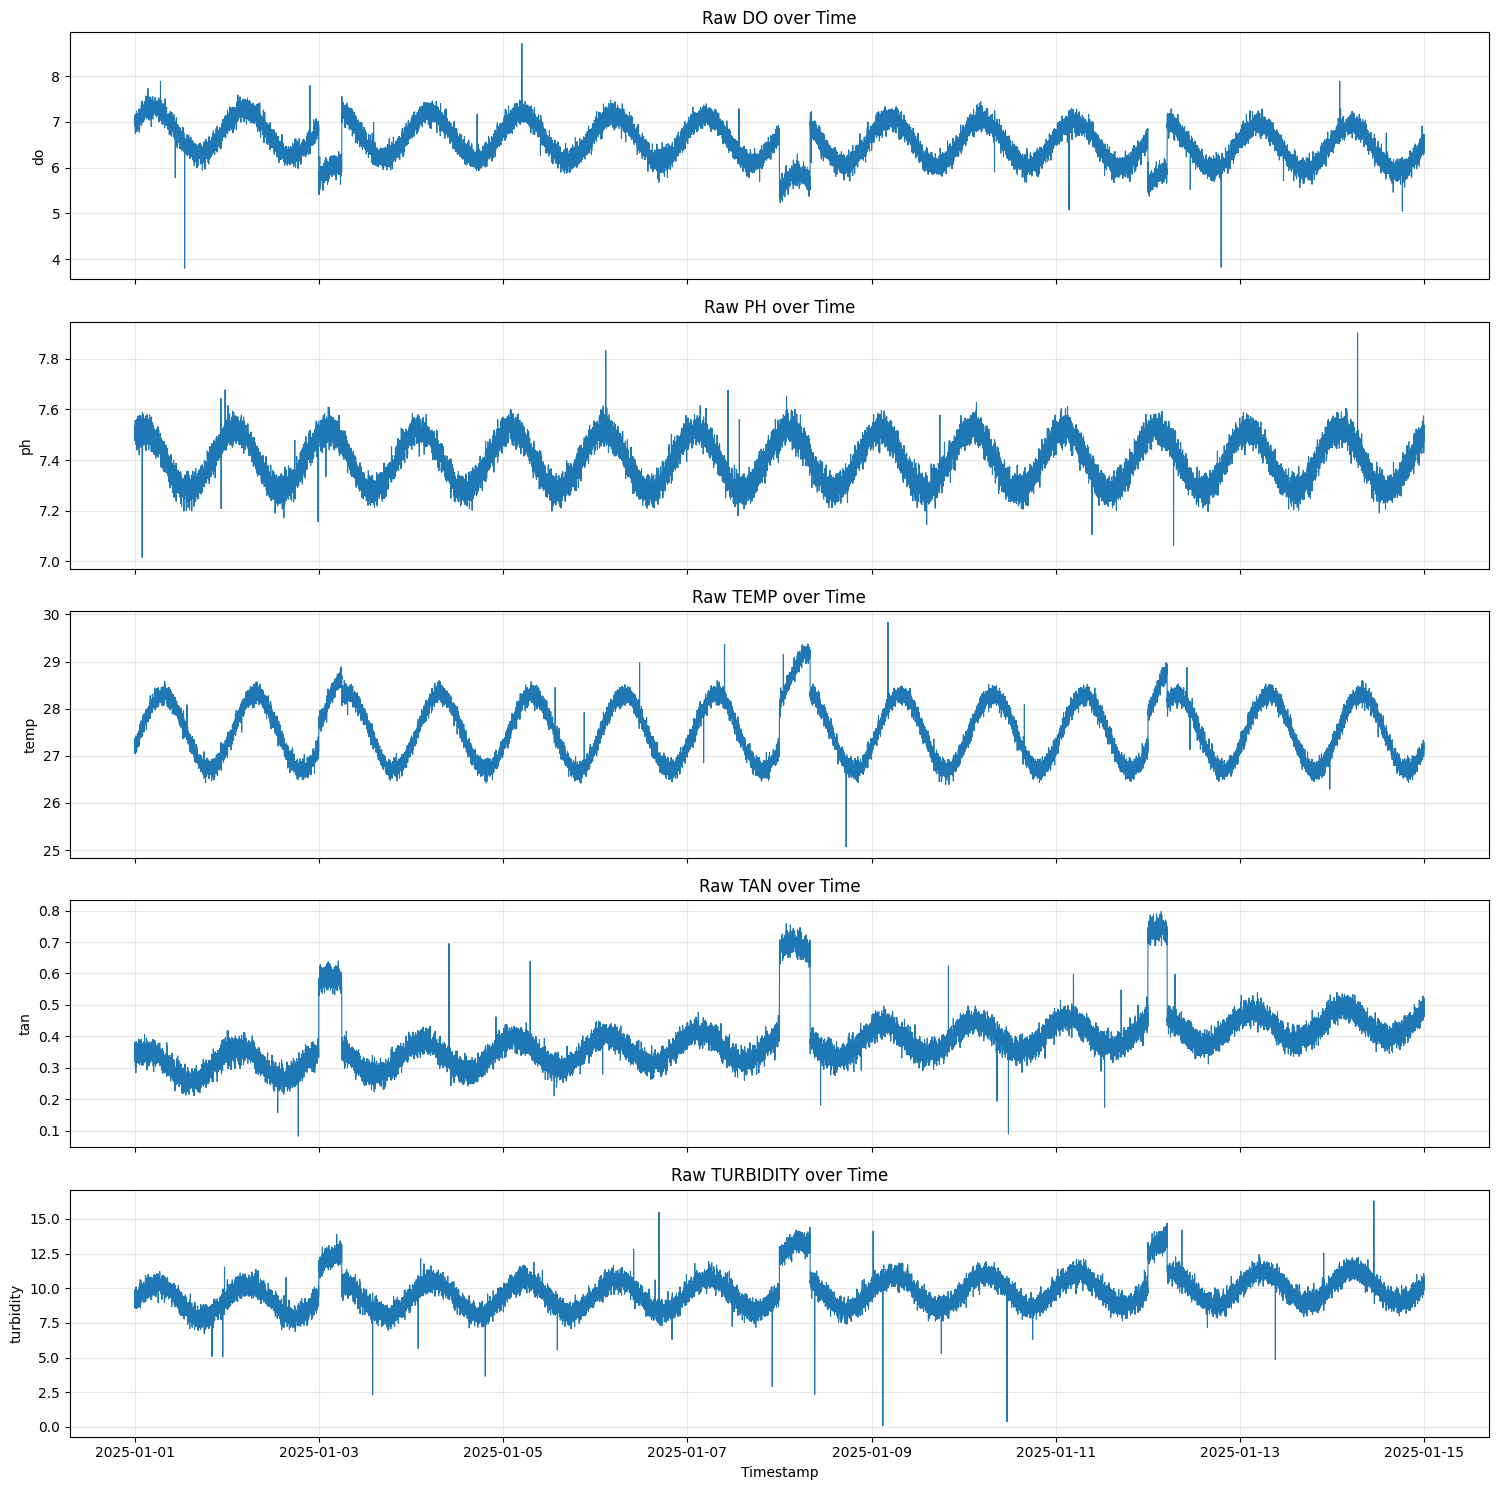

In [9]:
def plot_sensor_timeseries(df, columns, title_prefix="Raw"):
    fig, axes = plt.subplots(len(columns), 1, figsize=(15, 3 * len(columns)), sharex=True)

    if len(columns) == 1:
        axes = [axes]

    for ax, col in zip(axes, columns):
        ax.plot(df["timestamp"], df[col], linewidth=0.8)
        ax.set_title(f"{title_prefix} {col.upper()} over Time")
        ax.set_ylabel(col)
        ax.grid(alpha=0.3)

    plt.xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

plot_sensor_timeseries(sensor_df, SENSOR_COLUMNS, title_prefix="Raw")

In [10]:
def apply_median_filter(df, sensor_cols, window=5):
    filtered_df = df.copy()
    for col in sensor_cols:
        filtered_df[f"{col}_filtered"] = (
            filtered_df[col]
            .rolling(window=window, center=True, min_periods=1)
            .median()
        )
    return filtered_df

sensor_df = apply_median_filter(sensor_df, SENSOR_COLUMNS, window=MEDIAN_FILTER_WINDOW)

display(sensor_df.head())

,timestamp,tank_id,do,ph,temp,tan,turbidity,do_filtered,ph_filtered,temp_filtered,tan_filtered,turbidity_filtered
0,2025-01-01 00:00:00,tank_1,7.007366,7.511361,27.131727,0.349024,8.739518,7.007366,7.511361,27.155445,0.350220,9.099069
1,2025-01-01 00:01:00,tank_1,6.933231,7.477962,27.155445,0.380946,9.099069,7.018486,7.510569,27.180153,0.349622,9.166870
2,2025-01-01 00:02:00,tank_1,7.029606,7.523930,27.204861,0.350220,9.234671,7.007366,7.509776,27.204861,0.349024,9.234671
3,2025-01-01 00:03:00,tank_1,7.136704,7.509776,27.219940,0.321440,9.370712,6.933231,7.491881,27.204861,0.333364,9.370712
4,2025-01-01 00:04:00,tank_1,6.927896,7.491881,27.244868,0.333364,9.525092,7.029606,7.497093,27.219940,0.333364,9.453299


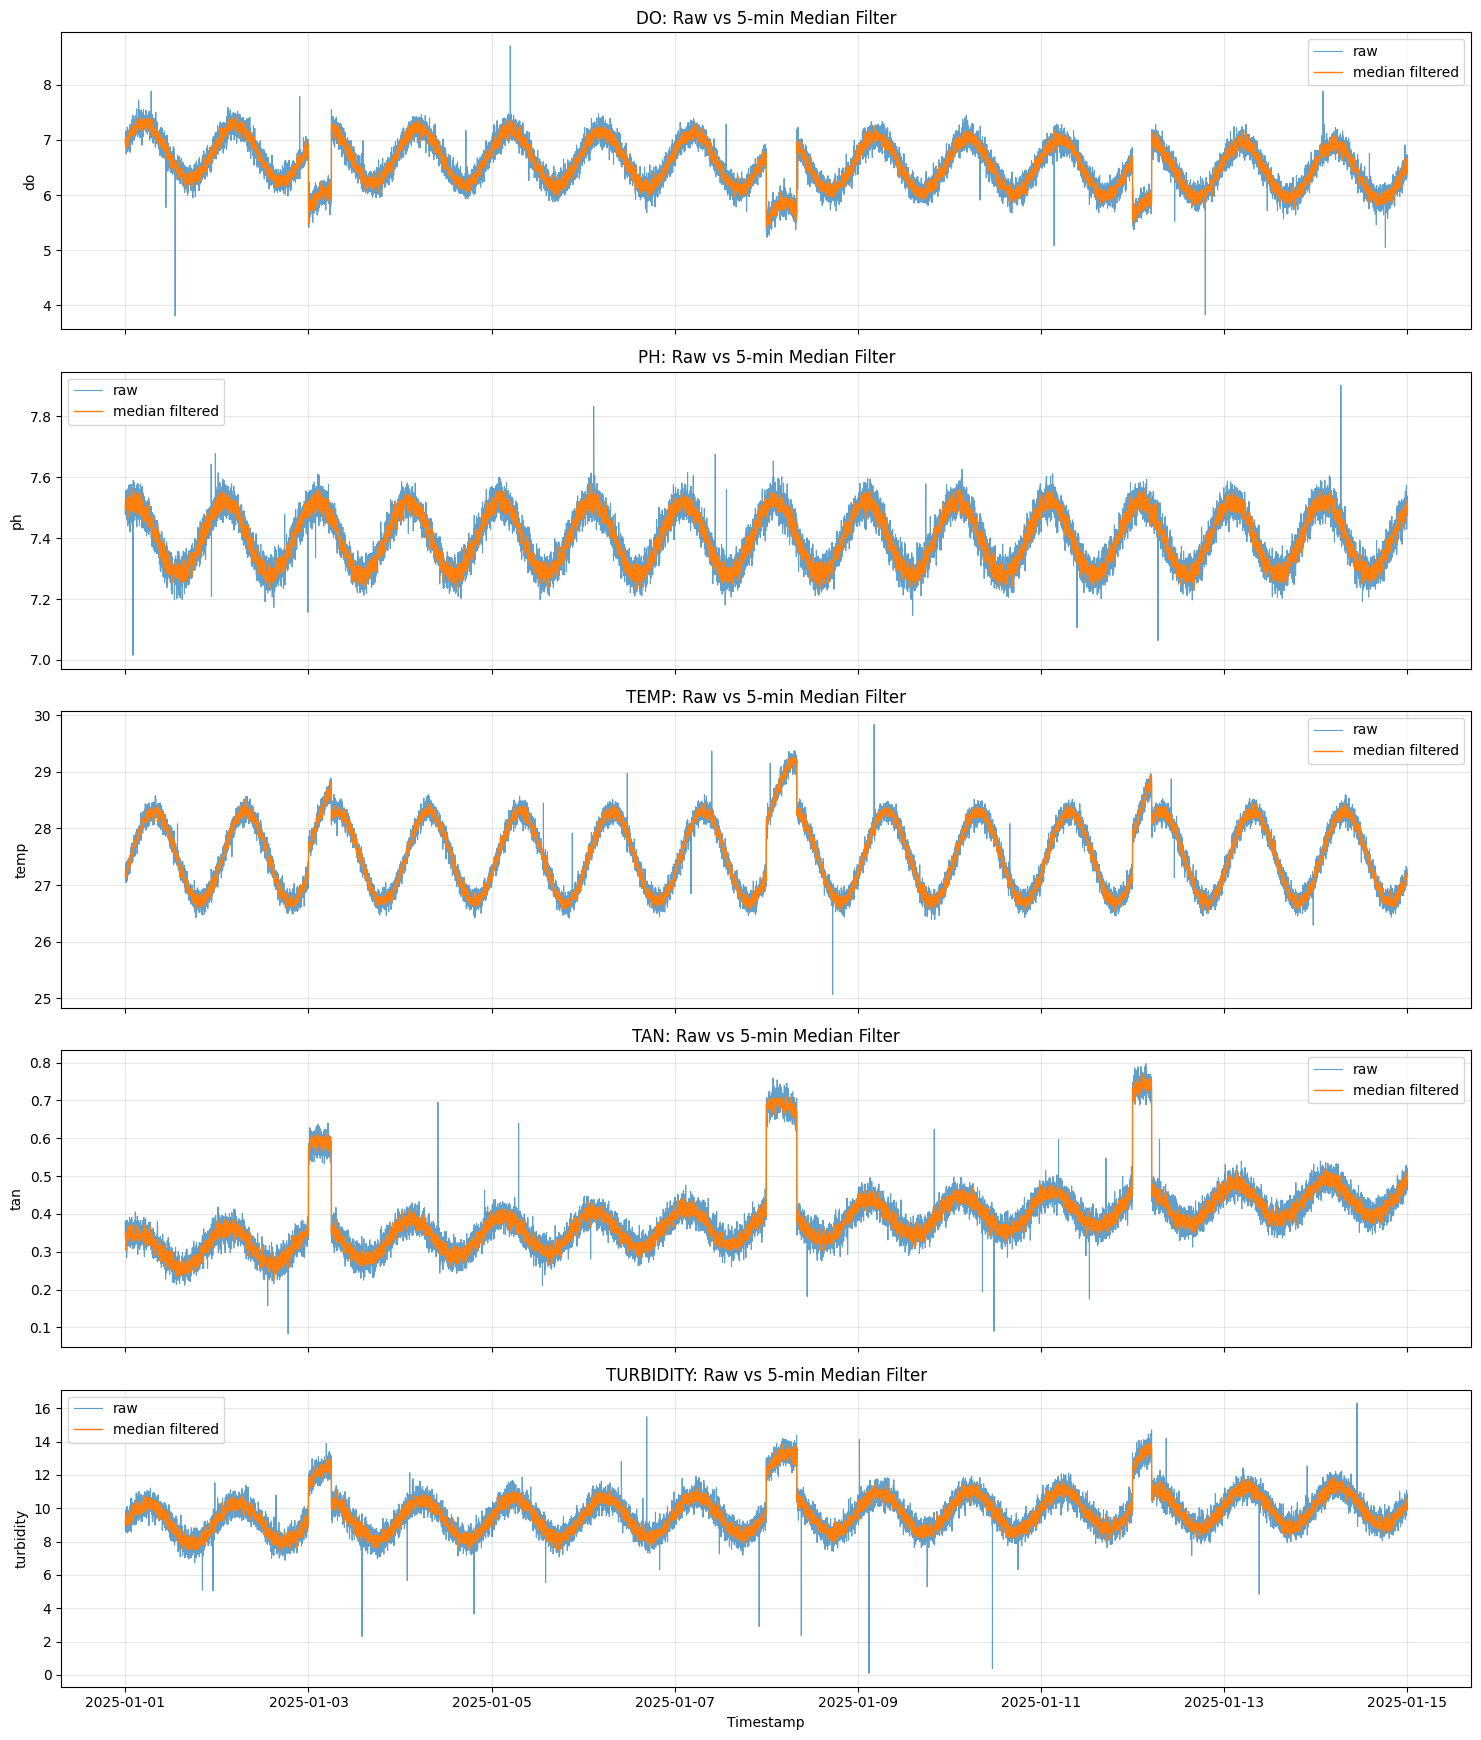

In [ ]:
def plot_raw_vs_filtered(df, sensor_cols):
    fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(15, 3.5 * len(sensor_cols)), sharex=True)

    if len(sensor_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, sensor_cols):
        ax.plot(df["timestamp"], df[col], label="raw", linewidth=0.8, alpha=0.7)
        ax.plot(df["timestamp"], df[f"{col}_filtered"], label="median filtered", linewidth=1.0)
        ax.set_title(f"{col.upper()}: Raw vs 5-min Median Filter")
        ax.set_ylabel(col)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

plot_raw_vs_filtered(sensor_df, SENSOR_COLUMNS)

In [11]:
def rolling_zscore(series, window=1440, min_periods=60, eps=1e-8):
    rolling_mean = series.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = series.rolling(window=window, min_periods=min_periods).std()
    z = (series - rolling_mean) / (rolling_std + eps)
    return z.fillna(0.0)


def add_anomaly_scores(df, sensor_cols, source_suffix="_filtered",
                       z_window=1440, min_periods=60):
    out = df.copy()
    for col in sensor_cols:
        source_col = f"{col}{source_suffix}"
        anomaly_col = f"a_{col}"
        out[anomaly_col] = rolling_zscore(
            out[source_col],
            window=z_window,
            min_periods=min_periods,
            eps=EPS
        )
    return out

sensor_df = add_anomaly_scores(
    sensor_df,
    SENSOR_COLUMNS,
    source_suffix="_filtered",
    z_window=ROLLING_Z_WINDOW,
    min_periods=MIN_PERIODS_Z
)

anomaly_cols = [f"a_{col}" for col in SENSOR_COLUMNS]
display(sensor_df[["timestamp"] + anomaly_cols].head())

,timestamp,a_do,a_ph,a_temp,a_tan,a_turbidity
0,2025-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0
1,2025-01-01 00:01:00,0.0,0.0,0.0,0.0,0.0
2,2025-01-01 00:02:00,0.0,0.0,0.0,0.0,0.0
3,2025-01-01 00:03:00,0.0,0.0,0.0,0.0,0.0
4,2025-01-01 00:04:00,0.0,0.0,0.0,0.0,0.0


In [12]:
ANOMALY_THRESHOLD = 2.0

def add_anomaly_flags(df, anomaly_columns, threshold=2.0):
    out = df.copy()
    for col in anomaly_columns:
        out[f"{col}_flag"] = (out[col].abs() > threshold).astype(int)
    out["any_anomaly_flag"] = out[[f"{col}_flag" for col in anomaly_columns]].max(axis=1)
    return out

sensor_df = add_anomaly_flags(sensor_df, anomaly_cols, threshold=ANOMALY_THRESHOLD)

display(sensor_df[["timestamp"] + anomaly_cols + ["any_anomaly_flag"]].head(10))

,timestamp,a_do,a_ph,a_temp,a_tan,a_turbidity,any_anomaly_flag
0,2025-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0
1,2025-01-01 00:01:00,0.0,0.0,0.0,0.0,0.0,0
2,2025-01-01 00:02:00,0.0,0.0,0.0,0.0,0.0,0
3,2025-01-01 00:03:00,0.0,0.0,0.0,0.0,0.0,0
4,2025-01-01 00:04:00,0.0,0.0,0.0,0.0,0.0,0
5,2025-01-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0
6,2025-01-01 00:06:00,0.0,0.0,0.0,0.0,0.0,0
7,2025-01-01 00:07:00,0.0,0.0,0.0,0.0,0.0,0
8,2025-01-01 00:08:00,0.0,0.0,0.0,0.0,0.0,0
9,2025-01-01 00:09:00,0.0,0.0,0.0,0.0,0.0,0


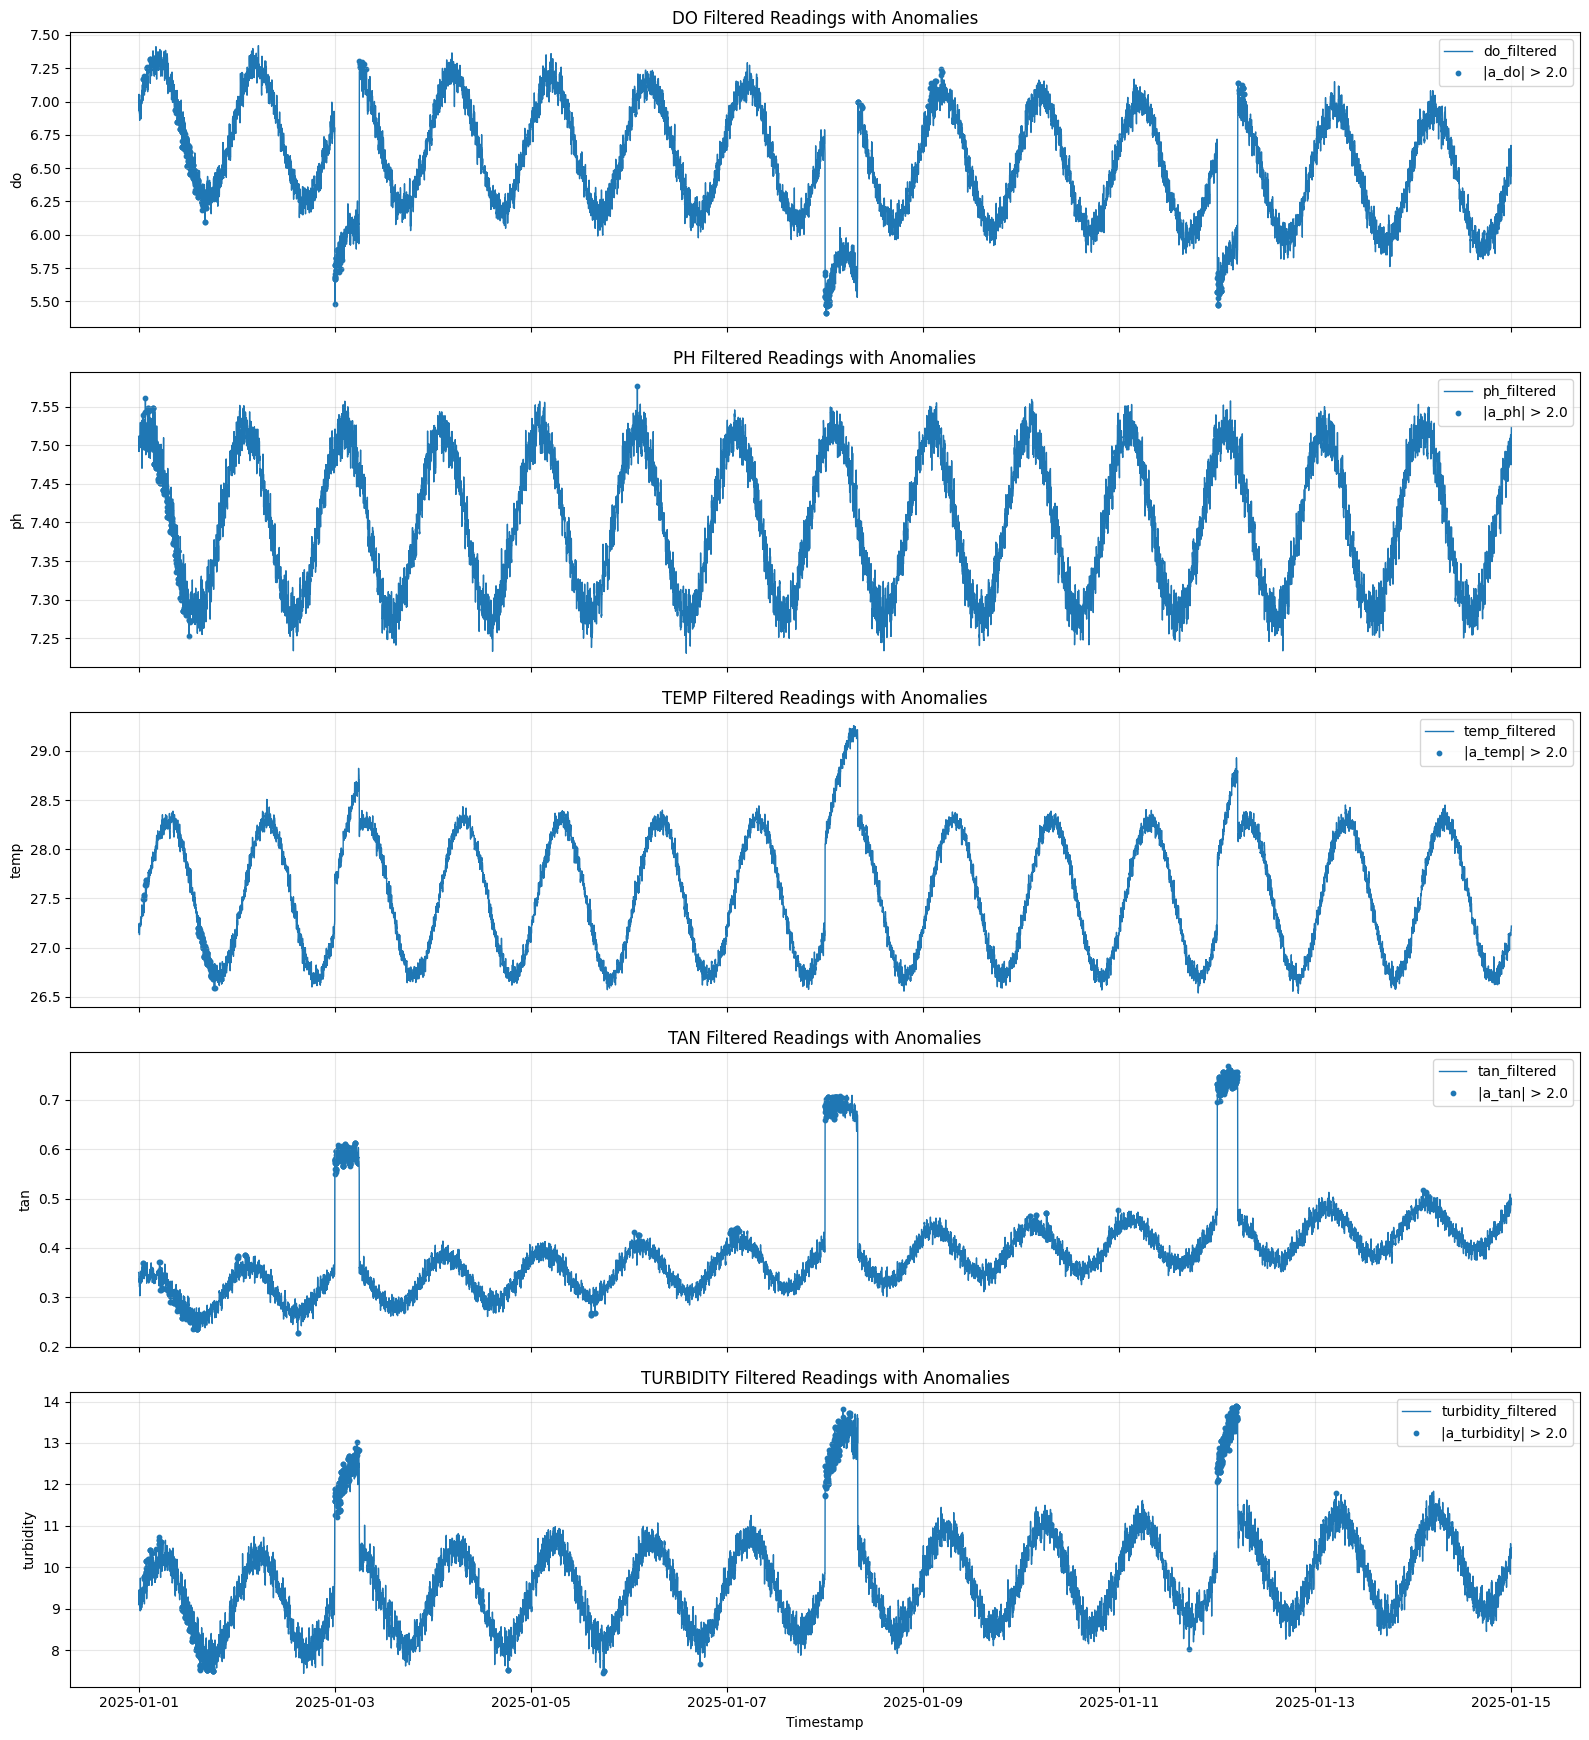

In [13]:
def plot_filtered_with_anomalies(df, sensor_cols, anomaly_threshold=2.0):
    fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(16, 3.5 * len(sensor_cols)), sharex=True)

    if len(sensor_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, sensor_cols):
        filtered_col = f"{col}_filtered"
        anomaly_col = f"a_{col}"

        ax.plot(df["timestamp"], df[filtered_col], linewidth=1.0, label=f"{filtered_col}")

        mask = df[anomaly_col].abs() > anomaly_threshold
        ax.scatter(
            df.loc[mask, "timestamp"],
            df.loc[mask, filtered_col],
            s=10,
            label=f"|{anomaly_col}| > {anomaly_threshold}"
        )

        ax.set_title(f"{col.upper()} Filtered Readings with Anomalies")
        ax.set_ylabel(col)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

plot_filtered_with_anomalies(sensor_df, SENSOR_COLUMNS, anomaly_threshold=ANOMALY_THRESHOLD)

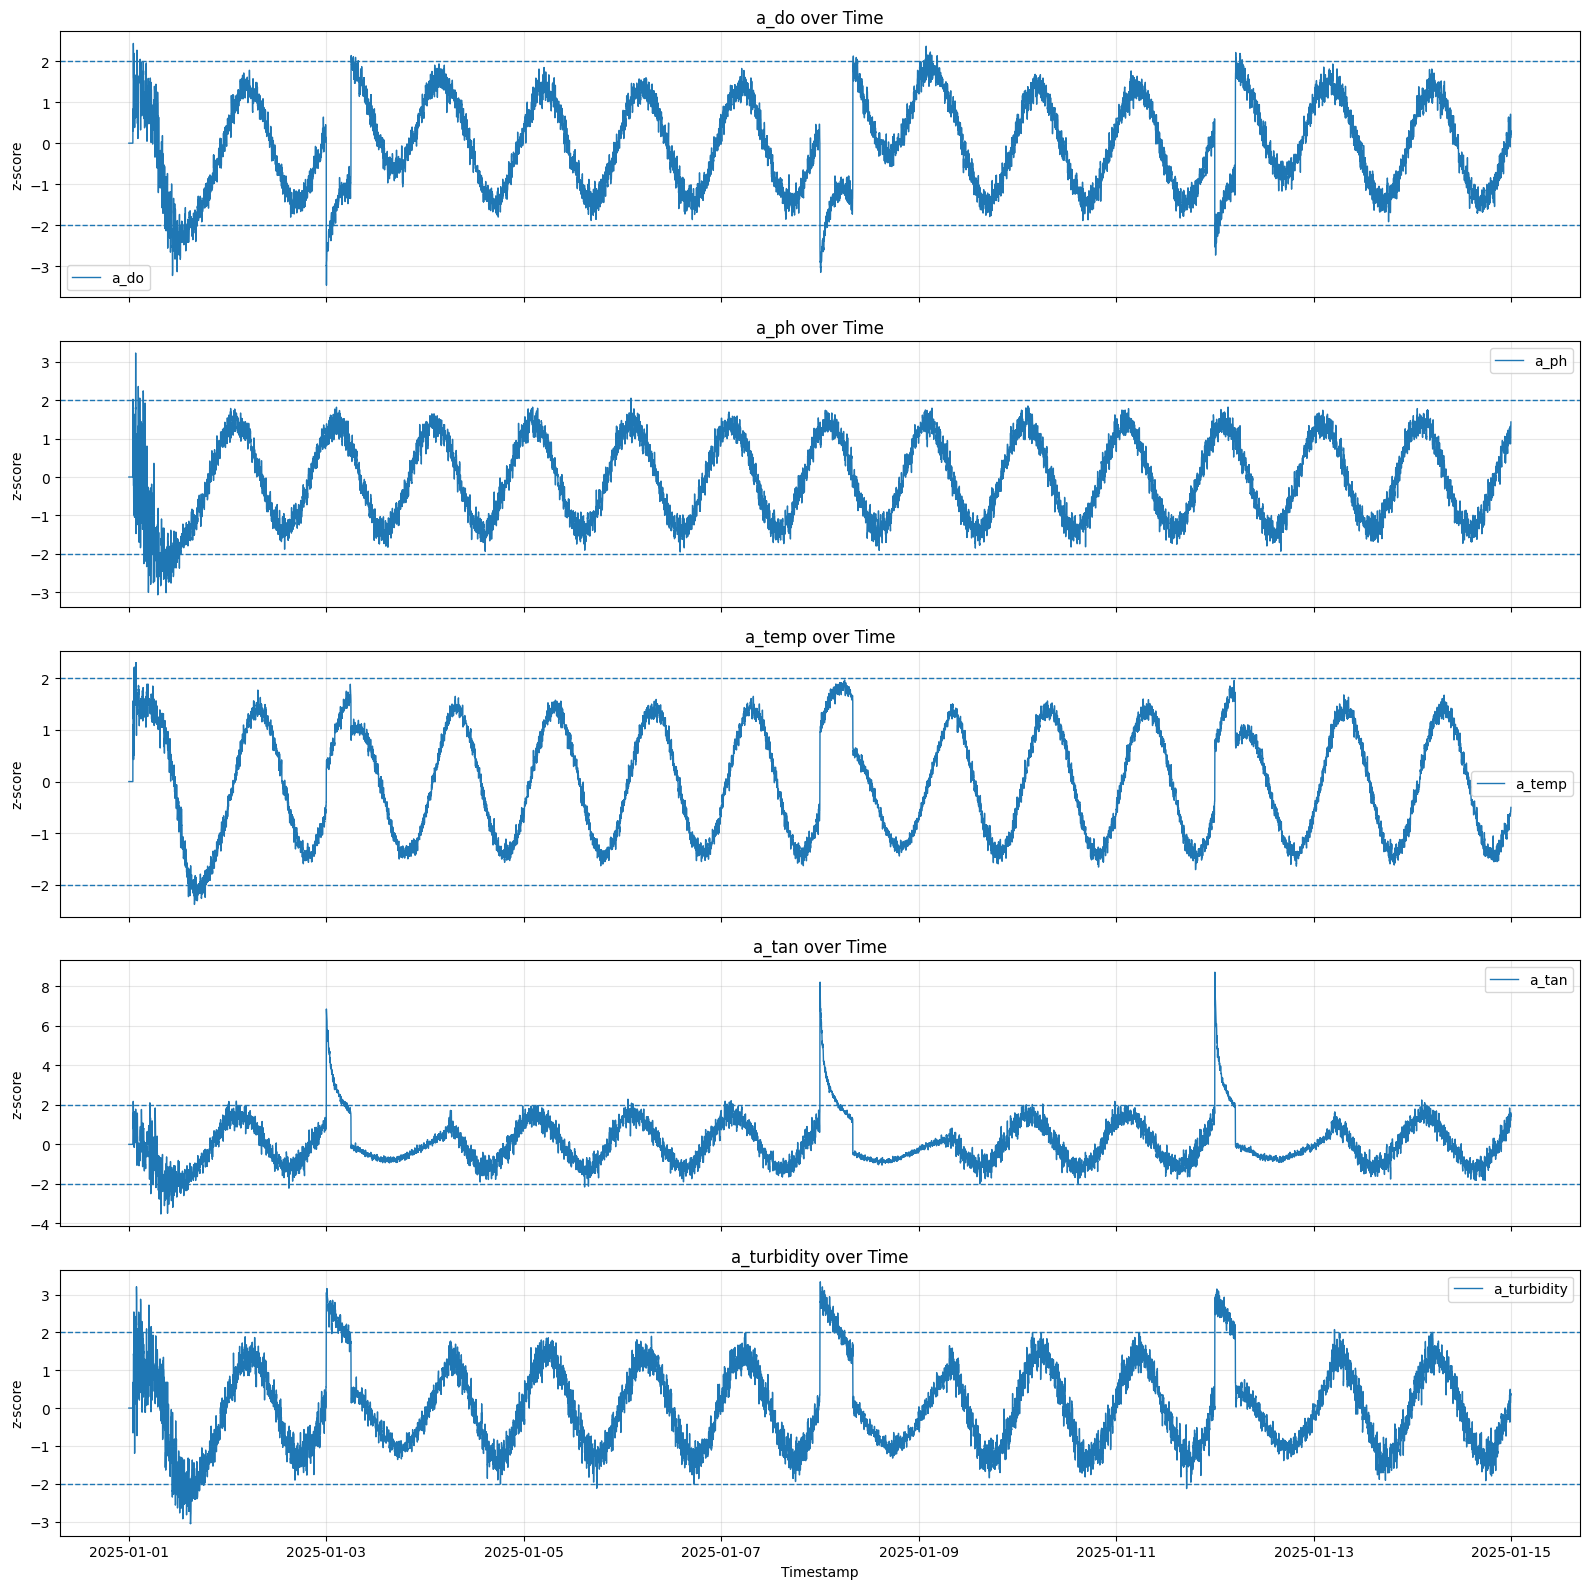

In [14]:
def plot_anomaly_scores(df, anomaly_columns, threshold=2.0):
    fig, axes = plt.subplots(len(anomaly_columns), 1, figsize=(16, 3.2 * len(anomaly_columns)), sharex=True)

    if len(anomaly_columns) == 1:
        axes = [axes]

    for ax, col in zip(axes, anomaly_columns):
        ax.plot(df["timestamp"], df[col], linewidth=1.0, label=col)
        ax.axhline(threshold, linestyle="--", linewidth=1)
        ax.axhline(-threshold, linestyle="--", linewidth=1)
        ax.set_title(f"{col} over Time")
        ax.set_ylabel("z-score")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

plot_anomaly_scores(sensor_df, anomaly_cols, threshold=ANOMALY_THRESHOLD)

In [15]:
def build_feature_vector_table(df):
    feature_df = pd.DataFrame({
        "timestamp": df["timestamp"],
        "tank_id": df["tank_id"],
        "do": df["do_filtered"],
        "ph": df["ph_filtered"],
        "temp": df["temp_filtered"],
        "tan": df["tan_filtered"],
        "turbidity": df["turbidity_filtered"],
        "a_do": df["a_do"],
        "a_ph": df["a_ph"],
        "a_temp": df["a_temp"],
        "a_tan": df["a_tan"],
        "a_turbidity": df["a_turbidity"],
        "any_anomaly_flag": df["any_anomaly_flag"]
    })
    return feature_df

feature_df = build_feature_vector_table(sensor_df)

print(feature_df.shape)
display(feature_df.head())

(20160, 13)


,timestamp,tank_id,do,ph,temp,tan,turbidity,a_do,a_ph,a_temp,a_tan,a_turbidity,any_anomaly_flag
0,2025-01-01 00:00:00,tank_1,7.007366,7.511361,27.155445,0.350220,9.099069,0.0,0.0,0.0,0.0,0.0,0
1,2025-01-01 00:01:00,tank_1,7.018486,7.510569,27.180153,0.349622,9.166870,0.0,0.0,0.0,0.0,0.0,0
2,2025-01-01 00:02:00,tank_1,7.007366,7.509776,27.204861,0.349024,9.234671,0.0,0.0,0.0,0.0,0.0,0
3,2025-01-01 00:03:00,tank_1,6.933231,7.491881,27.204861,0.333364,9.370712,0.0,0.0,0.0,0.0,0.0,0
4,2025-01-01 00:04:00,tank_1,7.029606,7.497093,27.219940,0.333364,9.453299,0.0,0.0,0.0,0.0,0.0,0


In [16]:
display(feature_df.describe().T)

,count,mean,min,25%,50%,75%,max,std
timestamp,20160,2025-01-07 23:59:30.000000256,2025-01-01 00:00:00,2025-01-04 11:59:45,2025-01-07 23:59:30,2025-01-11 11:59:15,2025-01-14 23:59:00,NaN
do,20160.0,6.534625,5.411222,6.201839,6.508959,6.891832,7.419225,0.407982
ph,20160.0,7.399706,7.230785,7.316668,7.39934,7.482609,7.576874,0.086424
temp,20160.0,27.539572,26.535921,26.930385,27.535989,28.116937,29.255598,0.612203
tan,20160.0,0.3894,0.226967,0.334514,0.377282,0.422876,0.769278,0.088283
turbidity,20160.0,9.73412,7.439496,8.839052,9.612897,10.442728,13.895621,1.168821
a_do,20160.0,-0.08128,-3.46706,-1.042077,-0.108267,0.916923,2.434816,1.088575
a_ph,20160.0,-0.059311,-3.061702,-1.016997,-0.080477,0.924091,3.222005,1.03517
a_temp,20160.0,-0.013501,-2.379232,-1.044205,-0.014736,0.983889,2.303386,1.050344
a_tan,20160.0,0.070281,-3.529159,-0.755232,-0.168613,0.814256,8.720392,1.181599


In [17]:
anomalous_rows = feature_df[feature_df["any_anomaly_flag"] == 1].copy()

print(f"Number of rows with at least one anomaly: {len(anomalous_rows)}")
display(anomalous_rows.head(20))

Number of rows with at least one anomaly: 1725


,timestamp,tank_id,do,ph,temp,tan,turbidity,a_do,a_ph,a_temp,a_tan,a_turbidity,any_anomaly_flag
60,2025-01-01 01:00:00,tank_1,7.044709,7.538607,27.360355,0.357791,9.177546,0.822860,2.020109,1.059187,1.574465,-0.656117,1
63,2025-01-01 01:03:00,tank_1,7.044709,7.521213,27.389485,0.368502,9.400202,0.814643,0.780388,1.345355,2.177511,0.676023,1
64,2025-01-01 01:04:00,tank_1,7.067390,7.521213,27.411513,0.369705,9.207822,1.117809,0.770797,1.566029,2.158511,-0.498061,1
65,2025-01-01 01:05:00,tank_1,7.169933,7.515159,27.411513,0.368502,9.434365,2.434816,0.372062,1.525780,1.997430,0.886182,1
66,2025-01-01 01:06:00,tank_1,7.169933,7.506195,27.411513,0.369705,9.434365,2.315093,-0.215850,1.488494,1.996246,0.874457,1
71,2025-01-01 01:11:00,tank_1,7.126537,7.494367,27.490059,0.345883,9.530356,1.533209,-0.989963,2.192612,0.407019,1.318291,1
72,2025-01-01 01:12:00,tank_1,7.126537,7.494367,27.490059,0.345883,9.534523,1.498547,-0.976629,2.108484,0.403796,1.317661,1
73,2025-01-01 01:13:00,tank_1,7.190600,7.494367,27.448485,0.345883,9.764309,2.195088,-0.963821,1.618037,0.400649,2.542054,1
74,2025-01-01 01:14:00,tank_1,7.104161,7.501496,27.448485,0.348990,9.764309,1.141409,-0.475617,1.579655,0.592616,2.421736,1
75,2025-01-01 01:15:00,tank_1,7.104161,7.512500,27.448485,0.363476,9.764309,1.124252,0.273801,1.543890,1.484428,2.317060,1


In [18]:
from pathlib import Path

output_dir = Path("/content/drive/MyDrive/aquasense/notebook1_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

raw_sensor_path = output_dir / "sensor_data_raw_simulated.csv"
processed_sensor_path = output_dir / "sensor_data_processed_with_anomalies.csv"
feature_path = output_dir / "sensor_feature_vector_10d.csv"

sensor_df.to_csv(processed_sensor_path, index=False)
feature_df.to_csv(feature_path, index=False)

# Save raw simulation separately if needed
base_cols = ["timestamp", "tank_id"] + SENSOR_COLUMNS
sensor_df[base_cols].to_csv(raw_sensor_path, index=False)

print("Saved files:")
print(raw_sensor_path)
print(processed_sensor_path)
print(feature_path)

Saved files:
/content/drive/MyDrive/aquasense/notebook1_outputs/sensor_data_raw_simulated.csv
/content/drive/MyDrive/aquasense/notebook1_outputs/sensor_data_processed_with_anomalies.csv
/content/drive/MyDrive/aquasense/notebook1_outputs/sensor_feature_vector_10d.csv


In [19]:
required_feature_columns = [
    "do", "ph", "temp", "tan", "turbidity",
    "a_do", "a_ph", "a_temp", "a_tan", "a_turbidity"
]

missing = [c for c in required_feature_columns if c not in feature_df.columns]

if len(missing) == 0:
    print("Success: 10-dimensional feature vector created correctly.")
else:
    print("Missing columns:", missing)

display(feature_df[required_feature_columns].head())

Success: 10-dimensional feature vector created correctly.


,do,ph,temp,tan,turbidity,a_do,a_ph,a_temp,a_tan,a_turbidity
0,7.007366,7.511361,27.155445,0.350220,9.099069,0.0,0.0,0.0,0.0,0.0
1,7.018486,7.510569,27.180153,0.349622,9.166870,0.0,0.0,0.0,0.0,0.0
2,7.007366,7.509776,27.204861,0.349024,9.234671,0.0,0.0,0.0,0.0,0.0
3,6.933231,7.491881,27.204861,0.333364,9.370712,0.0,0.0,0.0,0.0,0.0
4,7.029606,7.497093,27.219940,0.333364,9.453299,0.0,0.0,0.0,0.0,0.0
